In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print('Model is ready')

c:\Users\ak60492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Model is ready


In [11]:
from langchain_community.tools import tool
from langchain_community.tools import DuckDuckGoSearchResults, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def get_news(query:str) -> str:
    """Helps to get news details for any specific subject"""
    duckDuckGoTool = DuckDuckGoSearchResults()
    return duckDuckGoTool.invoke(query)

@tool
def get_wikipedia_information(query: str) -> str:
    """Gets the information about historical topics"""
    print('get_wikipedia_information called')
    wikipedia_api_wrapper = WikipediaAPIWrapper(
        top_k_search=2,
        doc_content_chars_max=500
    )
    wikipedia_tool = WikipediaQueryRun(api_wrapper=wikipedia_api_wrapper)
    result = wikipedia_tool.run(query)
    print(result)
    return f"Result {result}"
get_news
get_wikipedia_information

StructuredTool(name='get_wikipedia_information', description='Gets the information about historical topics', args_schema=<class 'langchain_core.utils.pydantic.get_wikipedia_information'>, func=<function get_wikipedia_information at 0x000001E3BD535A80>)

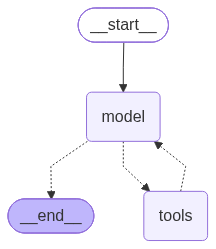

In [7]:
from langchain.agents import create_agent

ALL_TOOLS = [get_news, get_wikipedia_information]

agent = create_agent(
    model=model,
    tools=ALL_TOOLS,
    system_prompt="You are a helpful assistant. You can provide the news information with the help of get_news tool and to get information about history please call get_wikipedia_information tool"
)

agent

In [4]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What are the headlines of recent BRICS summit?"}
    ]
})

response

{'messages': [HumanMessage(content='What are the headlines of recent BRICS summit?', additional_kwargs={}, response_metadata={}, id='d3e4c22e-efe6-4dd4-8f83-34b22037eebe'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-15T04:56:37.99242909Z', 'done': True, 'done_reason': 'stop', 'total_duration': 350309247, 'load_duration': None, 'prompt_eval_count': 157, 'prompt_eval_duration': None, 'eval_count': 51, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0a36c-950e-70d1-be33-64d91919f530-0', tool_calls=[{'name': 'get_news', 'args': {'query': 'BRICS summit headlines recent'}, 'id': '4bcdc700-38e6-415c-a5e7-acf335fe798c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 157, 'output_tokens': 51, 'total_tokens': 208}),
  ToolMessage(content="snippet: Brics summit News: Check here latest news and updates about Brics summit in India. R

In [12]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What the phases in the history of Artificial Intelligence?"}
    ]
})

response

{'messages': [HumanMessage(content='What the phases in the history of Artificial Intelligence?', additional_kwargs={}, response_metadata={}, id='ea8d6264-9b0d-4530-aebd-ec9bf379f747'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-15T05:10:27.011007803Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1780820028, 'load_duration': None, 'prompt_eval_count': 195, 'prompt_eval_duration': None, 'eval_count': 70, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0a379-3614-7571-b95a-b5264659216b-0', tool_calls=[{'name': 'get_wikipedia_information', 'args': {'query': 'History of artificial intelligence phases'}, 'id': 'fa2061f2-cc98-4bd8-8cac-0e0cdce21bf1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 195, 'output_tokens': 70, 'total_tokens': 265}),
  ToolMessage(content='Page: History of artificial intelligence\nSummary:

In [13]:
from dotenv import load_dotenv, find_dotenv
import os
env_path = find_dotenv()
load_dotenv(env_path)

tavilyApiKey = os.getenv("TAVILY_API_KEY")
print('Tavily API Key is ready')

Tavily API Key is ready


In [14]:
from tavily import TavilyClient
from langchain_community.tools import TavilySearchResults
tavily_tool = TavilySearchResults(max_results=5)
result = tavily_tool.invoke("What are the headlines of recent BRICS summit?")
result

C:\Users\ak60492\AppData\Local\Temp\ipykernel_36540\484619987.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


[{'title': 'brics',
  'url': 'https://en.wikipedia.org/wiki/BRICS',
  'content': '| 12th | 21–23 July 2020 (postponed due to COVID-19 pandemic)( 17 November 2020 (video conference)( | Image 38: RussiaRussia | Vladimir Putin | Saint Petersburg( | Held virtually due to the COVID-19 pandemic; addressed pandemic response, public health coordination, and economic recovery.( | Moscow Declaration |\n| 13th | 9 September 2021 (video conference) | Image 39: IndiaIndia | Narendra Modi | New Delhi | Themed "BRICS@15: Intra-BRICS Cooperation for Continuity, Consolidation and Consensus"; addressed counterterrorism, digital health, and multilateral system reforms.( | New Delhi Declaration |\n| 14th | 23 June 2022 (video conference) | Image 40: ChinaChina | Xi Jinping | Beijing | Held virtually; leaders discussed international trade resilience, pandemic recovery, and preliminary proposals for alternative international reserve settlement mechanisms. | Beijing Declaration |\n| 15th | 22–24 August 2023 